In [35]:
# sources used 
# KNN: https://www.youtube.com/watch?v=TKfTKA5EmmY
# Read Image: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
# Iterate Folders: https://claude.ai/share/3ee51108-c4c4-44f8-9e00-d8ff087f1a2c 

# Dataset Overview
Dataset being used to the larger MNIST dataset of 60,000 images and 10 features (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
Each image in 28 by 28 pixel

In [36]:
# imports 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
from numpy import asarray
import pandas as pd
from pathlib import Path
import numpy as np


In [37]:
# Step 1: Preprocess the images into numpy arrays
img = Image.open('MNIST/0/000001.png')
print(img.size)

(28, 28)


In [38]:
pixel_array = asarray(img)
print(pixel_array)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 25

(-0.5, 27.5, 27.5, -0.5)

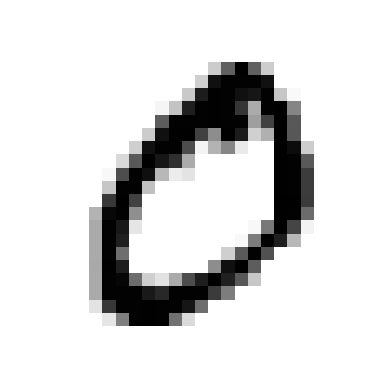

In [39]:
# turnings the 2D array back into an image
import matplotlib.pyplot as plt
plt.imshow(pixel_array, cmap=plt.cm.gray_r)
plt.axis('off')

why would we want to flatten an image?
ans: image needs to be flattened for iteration purporses
the feature of a single sample data must be stored in a 1D array
while all the sample data must be stored in a 2D array

In [40]:
# flatten the numpy arrays
flat_image = pixel_array.ravel()
print('flattened image')
print(flat_image)



flattened image
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  51 159 253 159  50   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252
 253 122   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 163 252 252 252 253 252 252  9

In [41]:
# commented out as this will take forever to reload x_data
# setting up X (data) and Y (target)
# from the video, X is meant to be an array of flattened pixel arrays therefore

# x_data = []
# y_target = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# # loop will flatten each png within the MNIST folder, storing it in x_data
# mnist_path = Path('MNIST')
# for image_path in sorted(mnist_path.glob('*//*.png')):
#     img = Image.open(image_path) # retrieves image
#     pixel_array = asarray(img) # converts to 2D array
#     flat_image = pixel_array.ravel() # creates 1D array
#     x_data.append(flat_image) # adds to x_data

# # export this as a dataframe so we dont have to load this two hour thing each time
# import numpy as np
# x_data_array = np.array(x_data)
# np.savez_compressed('x_data.npz', data=x_data_array)

# y_target = []
# # since x_data was loaded in order we'll load y_target in order too
# for n in range (10):
#     for i in range(6000):
#         y_target.append(n)
# y_target_array = np.array(y_target)
# np.savez_compressed('y_target.npz', data=y_target_array)


In [42]:
# To reload x and y:
loaded = np.load('x_data.npz')
x_data = loaded['data']

loaded = np.load('y_target.npz')
y_target = loaded['data']

In [44]:
# shuffle the dataframe then split 70% training 30% test
x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, test_size=0.3,shuffle=True)

In [45]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)
model_predict = model.predict(x_test)    
accuracy_score(y_test, model_predict)

0.9093888888888889

In [46]:
print(classification_report(y_test, model_predict))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1740
           1       0.85      0.96      0.90      1770
           2       0.86      0.83      0.84      1816
           3       0.83      0.84      0.83      1797
           4       0.84      0.84      0.84      1828
           5       0.94      0.87      0.91      1824
           6       0.98      0.97      0.98      1790
           7       0.93      0.96      0.94      1803
           8       0.98      0.89      0.93      1830
           9       0.94      0.96      0.95      1802

    accuracy                           0.91     18000
   macro avg       0.91      0.91      0.91     18000
weighted avg       0.91      0.91      0.91     18000



In [ ]:
# now the question remains is how to optimize it